# L=32 sweep: CPMC with a χ_T=8 DMRG trial, walker bond χ_w = 2, 4, 6

Runs from `run_mps_sweep.py` (`mps_cpmc_new.py` with the canonical-centre fix, adaptive plan, 200 walkers, 60 equilibration + 200 sampling blocks of 20 steps, Δτ = 0.01, U = 4, half filling). Data: `sweep_L32_T8/results.jsonl` (final blocking analysis), `sweep_L32_T8/blocks.jsonl` (every block, before trot's outlier rejection), and the run logs. Reference: DMRG at χ=200 from `study_dmrg_ref.jsonl`.

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from trot.stat_utils import reject_outliers

RUN = Path("sweep_L32_T8")
CHI_W = (2, 4, 6)
COLOR = {2: "#2a78d6", 4: "#eb6834", 6: "#1baf7a"}          # categorical slots 1-3, fixed per chi_w
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})

results = {json.loads(l)["walker_channel_chi"]: json.loads(l) for l in open(RUN / "results.jsonl")}
blocks = {w: [] for w in CHI_W}
for line in open(RUN / "blocks.jsonl"):
    r = json.loads(line)
    blocks[int(re.search(r"_w(\d+)_", r["tag"]).group(1))].append(r)
discarded = {}
for w in CHI_W:
    text = (RUN / f"L32_T8_w{w}_s1234.log").read_text()
    discarded[w] = float(re.search(r"discarded weights: ([0-9.e+-]+)", text).group(1))
E_ref = next(json.loads(l)["e_dmrg_chi200"] for l in open("study_dmrg_ref.jsonl") if json.loads(l)["L"] == 32)
E_trial = results[2]["trial_energy"]
n_eql = results[2]["n_equilibration"]

print(f"{'chi_w':>5} {'d=4 bond':>8} {'discarded/channel':>18} {'E_CPMC':>12} {'error':>8} {'E - E_ref':>10} {'nodes':>8}")
for w in CHI_W:
    r = results[w]
    print(f"{w:>5} {r['walker_d4_chi']:>8} {discarded[w]:18.2e} {r['cpmc_energy']:12.5f} {r['cpmc_error']:8.5f} "
          f"{r['cpmc_energy'] - E_ref:10.5f} {blocks[w][-1]['node_encounters']:>8}")
print(f"DMRG chi=200 reference {E_ref:.5f};  trial (chi_T=8) {E_trial:.5f}")

chi_w d=4 bond  discarded/channel       E_CPMC    error  E - E_ref    nodes
    2        4           7.59e-01    -17.92491  0.00507    0.06967    36475
    4       16           1.32e-01    -17.95418  0.00160    0.04040      417
    6       36           6.28e-03    -17.96806  0.00198    0.02652        0
DMRG chi=200 reference -17.99458;  trial (chi_T=8) -17.84894


## Energy against walker bond dimension

One point per run, with the error bar from trot's blocking analysis. The dashed line is the trial energy alone (χ_T = 8). The energy is still moving between χ_w = 4 and 6, so walker truncation is not converged at χ_w = 6. The second and third plots show why χ_w = 2 is so far off: it throws away 76% of the norm of each channel on the reference determinant, and the constraint then removes walkers far more often.

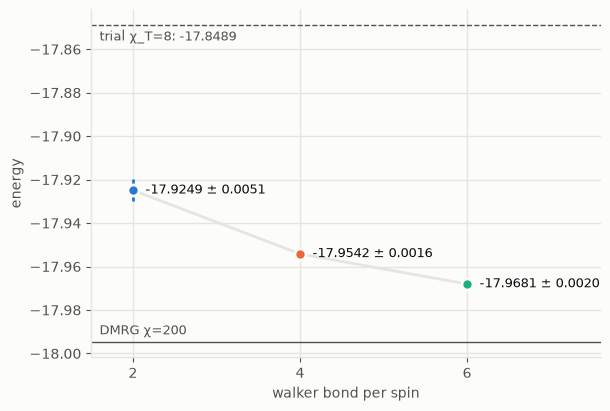

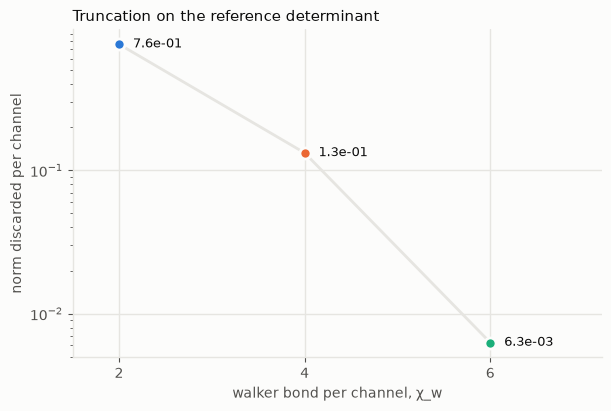

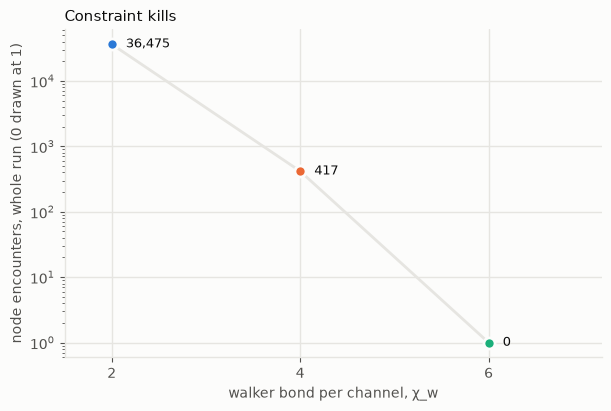

In [2]:
x = np.array(CHI_W)

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
E = np.array([results[w]["cpmc_energy"] for w in CHI_W])
err = np.array([results[w]["cpmc_error"] for w in CHI_W])
ax.axhline(E_ref, color=INK2, lw=1)
ax.text(1.6, E_ref + 0.002, "DMRG χ=200", color=INK2, va="bottom", fontsize=9)
ax.axhline(E_trial, color=INK2, lw=1, ls="--")
ax.text(1.6, E_trial - 0.002, f"trial χ_T=8: {E_trial:.4f}", color=INK2, va="top", fontsize=9)
ax.plot(x, E, color=GRID, lw=2, zorder=1)
for w, e, s in zip(CHI_W, E, err):
    ax.errorbar(w, e, yerr=s, fmt="o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, elinewidth=2, capsize=0, zorder=3)
    ax.text(w + 0.15, e, f"{e:.4f} ± {s:.4f}", color=INK, va="center", fontsize=9)
ax.set_xlim(1.5, 7.6)
ax.set_xticks(x)
ax.set_xlabel("walker bond per spin")
ax.set_ylabel("energy")
# ax.set_title("E_CPMC", loc="left")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
d = np.array([discarded[w] for w in CHI_W])
ax.plot(x, d, color=GRID, lw=2, zorder=1)
for w, v in zip(CHI_W, d):
    ax.plot(w, v, "o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, zorder=3)
    ax.text(w + 0.15, v, f"{v:.1e}", color=INK, va="center", fontsize=9)
ax.set_yscale("log")
ax.set_xlim(1.5, 7.2)
ax.set_xticks(x)
ax.set_xlabel("walker bond per channel, χ_w")
ax.set_ylabel("norm discarded per channel")
ax.set_title("Truncation on the reference determinant", loc="left")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
nodes = np.array([blocks[w][-1]["node_encounters"] for w in CHI_W])
shown = np.maximum(nodes, 1)
ax.plot(x, shown, color=GRID, lw=2, zorder=1)
for w, n, v in zip(CHI_W, nodes, shown):
    ax.plot(w, v, "o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, zorder=3)
    ax.text(w + 0.15, v, f"{n:,}", color=INK, va="center", fontsize=9)
ax.set_yscale("log")
ax.set_xlim(1.5, 7.2)
ax.set_xticks(x)
ax.set_xlabel("walker bond per channel, χ_w")
ax.set_ylabel("node encounters, whole run (0 drawn at 1)")
ax.set_title("Constraint kills", loc="left")
plt.show()

## Block energies through the run

Each panel is one run: the thin line is the energy of every block, the thick line the running weighted mean over the sampling blocks that trot's outlier filter keeps (so it ends at the reported value), and the shaded band the equilibration phase. The y-range is the same in all three panels. χ_w = 2 has two blocks above it, marked: block 237, which trot's filter rejected, and block 137, which it kept. Both are single walkers with tiny truncated overlaps blowing up the local energy.

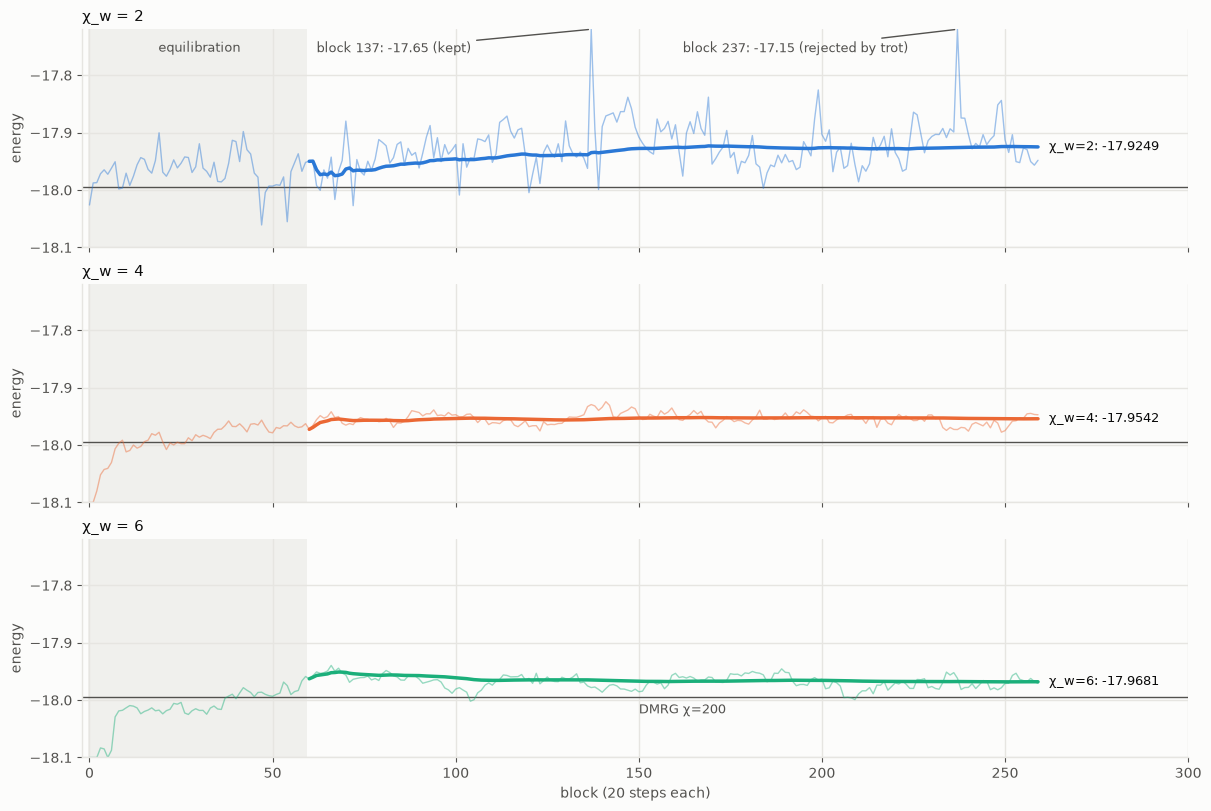

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=True, constrained_layout=True)
ylo, yhi = -18.10, -17.72
for ax, w in zip(axes, CHI_W):
    rs = blocks[w]
    b = np.array([r["block"] for r in rs])
    e = np.array([r["energy"] for r in rs])
    wt = np.array([r["weight"] for r in rs])
    s = b >= n_eql
    _, keep = reject_outliers(np.column_stack((e[s], wt[s])), obs=0)
    keep = np.asarray(keep)
    rejected = set(b[s][~keep].tolist())
    bs, es, ws = b[s][keep], e[s][keep], wt[s][keep]
    running = np.cumsum(es * ws) / np.cumsum(ws)
    ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
    ax.axhline(E_ref, color=INK2, lw=1)
    ax.plot(b, np.clip(e, ylo, yhi), color=COLOR[w], lw=1, alpha=0.45)
    ax.plot(bs, running, color=COLOR[w], lw=2.5)
    ax.text(b[-1] + 3, running[-1], f"χ_w={w}: {running[-1]:.4f}", color=INK, va="center", fontsize=9)
    for bi, ei in zip(b, e):
        if ei > yhi:
            status = "rejected by trot" if bi in rejected else "kept"
            ax.annotate(f"block {bi}: {ei:.2f} ({status})", xy=(bi, yhi), xytext=(bi - 75, yhi - 0.04),
                        color=INK2, fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=1))
    ax.set_ylabel("energy")
    ax.set_title(f"χ_w = {w}", loc="left")
axes[0].text(n_eql / 2, yhi - 0.02, "equilibration", color=INK2, ha="center", va="top", fontsize=9)
axes[-1].text(150, E_ref - 0.012, "DMRG χ=200", color=INK2, va="top", fontsize=9)
axes[-1].set_xlabel("block (20 steps each)")
axes[0].set_ylim(ylo, yhi)
axes[0].set_xlim(-2, 300)
plt.show()

## Population health

Total walker weight per block (left) and cumulative node encounters (right, log scale). With χ_w = 2 the weight drifts and dips, and the constraint fires about 140 times per block; with χ_w = 6 it never fires.

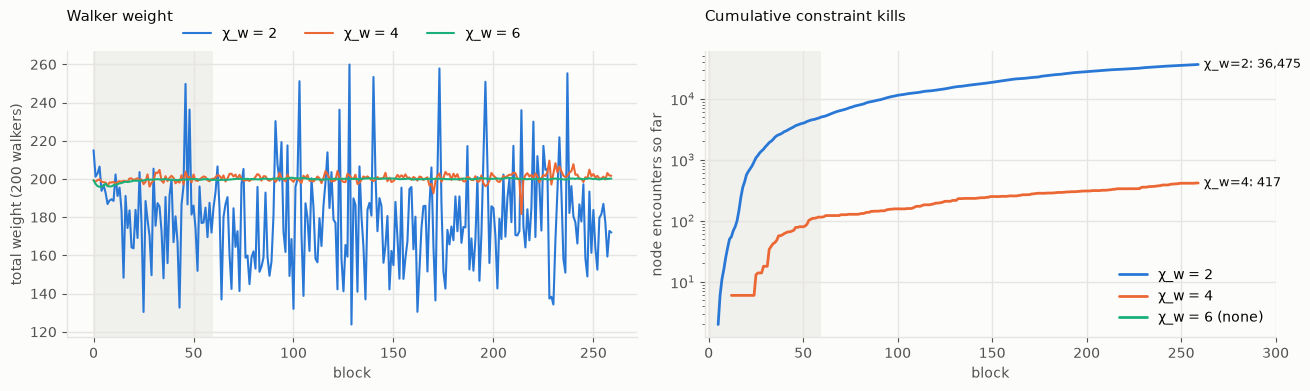

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True)
for w in CHI_W:
    rs = blocks[w]
    b = np.array([r["block"] for r in rs])
    axes[0].plot(b, [r["weight"] for r in rs], color=COLOR[w], lw=1.5, label=f"χ_w = {w}")
    n = np.array([r["node_encounters"] for r in rs], float)
    if n[-1] > 0:
        axes[1].plot(b, np.where(n > 0, n, np.nan), color=COLOR[w], lw=2, label=f"χ_w = {w}")
        axes[1].text(b[-1] + 3, n[-1], f"χ_w={w}: {int(n[-1]):,}", color=INK, va="center", fontsize=9)
    else:
        axes[1].plot([], [], color=COLOR[w], lw=2, label=f"χ_w = {w} (none)")
for ax in axes:
    ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
    ax.set_xlabel("block")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.13), ncol=3) if ax is axes[0] else ax.legend(loc="lower right")
axes[0].set_ylabel("total weight (200 walkers)")
axes[0].set_title("Walker weight", loc="left", pad=22)
axes[1].set_yscale("log")
axes[1].set_xlim(-2, 300)
axes[1].set_ylabel("node encounters so far")
axes[1].set_title("Cumulative constraint kills", loc="left", pad=22)
plt.show()

# U = 8: RHF vs natural-orbital kept counts

The same L = 32 runs (χ_T = 8, 200 walkers, 60 + 200 blocks of 20 steps, seed 1234) at U = 8, with two ways of freezing the per-sector kept counts of the walker MPS (approximation C):

- **RHF**: dry run on the free-fermion determinant, as in the U = 4 runs above (`sweep_L32_T8_U8/`);
- **NO**: dry run on the determinant of the trial's natural orbitals, `bond_reference="natural"` (`sweep_L32_T8_U8_NO/`).

Both use the same gate circuit (the adaptive plan built on RHF). Reference: DMRG χ = 200 at U = 8 (`sweep_L32_T8_U8/reference.jsonl`).

Some runs are still going. These cells read `blocks.jsonl` as it stands, so re-run them to update. A finished run shows trot's final blocking analysis (filled marker). An unfinished run shows the weighted mean of its sampling blocks so far (open marker), with a blocking error once it has 30 sampling blocks. A run whose total weight reached zero (every walker killed) is cut at that block. In this section **colour means the counts reference** (blue RHF, orange NO), not χ_w.

In [5]:
from trot.stat_utils import blocking_analysis_ratio

RUNS8 = {"RHF": Path("sweep_L32_T8_U8"), "NO": Path("sweep_L32_T8_U8_NO")}
REF_COLOR = {"RHF": "#2a78d6", "NO": "#eb6834"}              # categorical slots 1-2, fixed per counts reference
CHI_W8 = (2, 4, 6)
E_ref8 = json.loads(open(RUNS8["RHF"] / "reference.jsonl").readline())["e_variational"]
E_trial8 = json.loads(open(RUNS8["RHF"] / "results.jsonl").readline())["trial_energy"]


def read_jsonl(path):
    return [json.loads(line) for line in open(path)] if path.exists() else []


def summarise(ref, w):
    # Status, energy and error of one run from its per-block log (and results.jsonl once finished).
    tag = f"L32_U8_T8_w{w}{'_NO' if ref == 'NO' else ''}_s1234"
    rs = [r for r in read_jsonl(RUNS8[ref] / "blocks.jsonl") if r["tag"] == tag]
    done = {r["tag"]: r for r in read_jsonl(RUNS8[ref] / "results.jsonl")}.get(tag)
    run = dict(b=np.array([r["block"] for r in rs], int), e=np.array([r["energy"] for r in rs]),
               wt=np.array([r["weight"] for r in rs]), nodes=np.array([r["node_encounters"] for r in rs], int),
               collapsed=None, E=np.nan, err=np.nan, final=False)
    dead = np.flatnonzero(~(run["wt"] > 0))
    if len(dead):  # total weight zero: no walkers left, later blocks mean nothing
        run["collapsed"] = int(run["b"][dead[0]])
        for key in ("b", "e", "wt", "nodes"):
            run[key] = run[key][:dead[0]]
    sampling = run["b"] >= n_eql
    if sampling.any():
        _, keep = reject_outliers(np.column_stack((run["e"][sampling], run["wt"][sampling])), obs=0)
        keep = np.asarray(keep)
        run["kept_b"], ke, kw = run["b"][sampling][keep], run["e"][sampling][keep], run["wt"][sampling][keep]
        run["running"] = np.cumsum(ke * kw) / np.cumsum(kw)
    if run["collapsed"] is not None:
        run["status"] = f"collapsed at block {run['collapsed']}"
    elif done is not None:
        run.update(status="finished", E=done["cpmc_energy"], err=done["cpmc_error"], final=True)
    elif not len(rs):
        run["status"] = "no data yet"
    elif not sampling.any():
        run["status"] = f"equilibrating, block {run['b'][-1]}"
    else:
        run.update(status=f"running, block {run['b'][-1]}", E=run["running"][-1])
        if sampling.sum() >= 30:
            run["err"] = blocking_analysis_ratio(ke, kw, print_q=False)["se_star"]
    return run


runs8 = {(ref, w): summarise(ref, w) for ref in RUNS8 for w in CHI_W8}
print(f"{'counts':>6} {'chi_w':>5}  {'status':<26} {'E_CPMC':>10} {'error':>8} {'E - E_ref':>10} {'nodes':>9}")
for (ref, w), r in runs8.items():
    nodes = r["nodes"][-1] if len(r["nodes"]) else 0
    print(f"{ref:>6} {w:>5}  {r['status']:<26} {r['E']:10.5f} {r['err']:8.5f} {r['E'] - E_ref8:10.5f} {nodes:>9,}")
print(f"DMRG chi=200 reference {E_ref8:.5f};  trial (chi_T=8) {E_trial8:.5f}")

counts chi_w  status                         E_CPMC    error  E - E_ref     nodes
   RHF     2  collapsed at block 32             nan      nan        nan    36,927
   RHF     4  finished                    -10.20807  0.00373    0.06731    10,122
   RHF     6  finished                    -10.24128  0.00230    0.03410        38
    NO     2  finished                    -10.20135  0.00499    0.07402   170,060
    NO     4  running, block 76           -10.32809      nan   -0.05271       323
    NO     6  no data yet                       nan      nan        nan         0
DMRG chi=200 reference -10.27538;  trial (chi_T=8) -10.18317


## U = 8: energy against walker bond dimension

Left: the CPMC energy of each run, with RHF and NO counts side by side at each χ_w. A × at the top marks a collapsed population and the block where it happened. Right: how often the constraint fires, as node encounters per block up to the last block with live walkers.

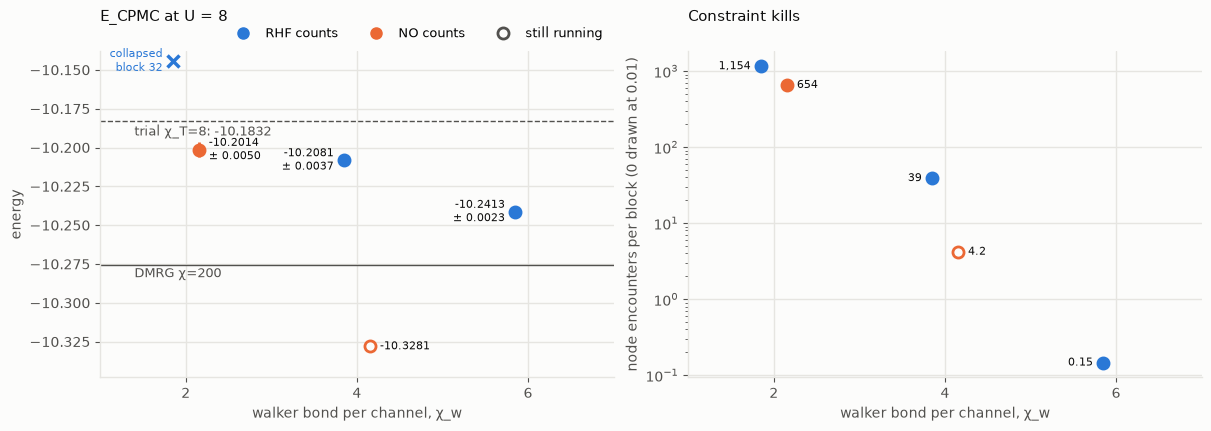

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
OFFSET = {"RHF": -0.15, "NO": 0.15}

ax = axes[0]
finite = [r["E"] for r in runs8.values() if np.isfinite(r["E"])]
lo, hi = min(finite + [E_ref8]) - 0.02, max(finite + [E_trial8]) + 0.045
ax.axhline(E_ref8, color=INK2, lw=1)
ax.text(1.4, E_ref8 - 0.002, "DMRG χ=200", color=INK2, va="top", fontsize=9)
ax.axhline(E_trial8, color=INK2, lw=1, ls="--")
ax.text(1.4, E_trial8 - 0.002, f"trial χ_T=8: {E_trial8:.4f}", color=INK2, va="top", fontsize=9)
for ref, c in REF_COLOR.items():
    side = 1 if ref == "NO" else -1
    for w in CHI_W8:
        r, x = runs8[(ref, w)], w + OFFSET[ref]
        if r["collapsed"] is not None:
            ax.plot(x, hi - 0.006, "x", ms=9, mew=2.5, color=c)
            ax.text(x + side * 0.12, hi - 0.006, f"collapsed\nblock {r['collapsed']}", color=c,
                    ha="left" if side > 0 else "right", va="center", fontsize=8)
        elif np.isfinite(r["E"]):
            ax.errorbar(x, r["E"], yerr=0.0 if np.isnan(r["err"]) else r["err"], fmt="o", ms=8, color=c,
                        mfc=c if r["final"] else SURFACE, mec=c, mew=2, elinewidth=2, capsize=0, zorder=3)
            label = f"{r['E']:.4f}" + ("" if np.isnan(r["err"]) else f"\n± {r['err']:.4f}")
            ax.text(x + side * 0.12, r["E"], label, color=INK, ha="left" if side > 0 else "right",
                    va="center", fontsize=8)
    ax.plot([], [], "o", ms=8, color=c, label=f"{ref} counts")
ax.plot([], [], "o", ms=8, mfc=SURFACE, mec=INK2, mew=2, label="still running")
ax.set_ylim(lo, hi)
ax.set_xlim(1.0, 7.0)
ax.set_xticks(CHI_W8)
ax.set_xlabel("walker bond per channel, χ_w")
ax.set_ylabel("energy")
ax.set_title("E_CPMC at U = 8", loc="left", pad=22)
ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=3, fontsize=9)

ax = axes[1]
for ref, c in REF_COLOR.items():
    side = 1 if ref == "NO" else -1
    for w in CHI_W8:
        r, x = runs8[(ref, w)], w + OFFSET[ref]
        if not len(r["b"]):
            continue
        rate = r["nodes"][-1] / len(r["b"])
        ax.plot(x, max(rate, 1e-2), "o", ms=8, color=c, mec=c, mew=2,
                mfc=c if r["final"] or r["collapsed"] is not None else SURFACE, zorder=3)
        ax.text(x + side * 0.12, max(rate, 1e-2), f"{rate:,.0f}" if rate >= 10 else f"{rate:.2g}", color=INK, ha="left" if side > 0 else "right",
                va="center", fontsize=8)
ax.set_yscale("log")
ax.set_xlim(1.0, 7.0)
ax.set_xticks(CHI_W8)
ax.set_xlabel("walker bond per channel, χ_w")
ax.set_ylabel("node encounters per block (0 drawn at 0.01)")
ax.set_title("Constraint kills", loc="left", pad=22)
plt.show()

## U = 8: block energies through the run

There is one panel per χ_w, with RHF and NO counts overlaid.
- Thin lines are the energy of every block.
- Thick lines are the running weighted mean over the sampling blocks that trot's outlier filter keeps, so a finished run ends at its reported value.
- The shaded band is equilibration.
- A dotted vertical line marks a collapse.
- Blocks outside the y-range are clipped to the edge and marked with a tick.

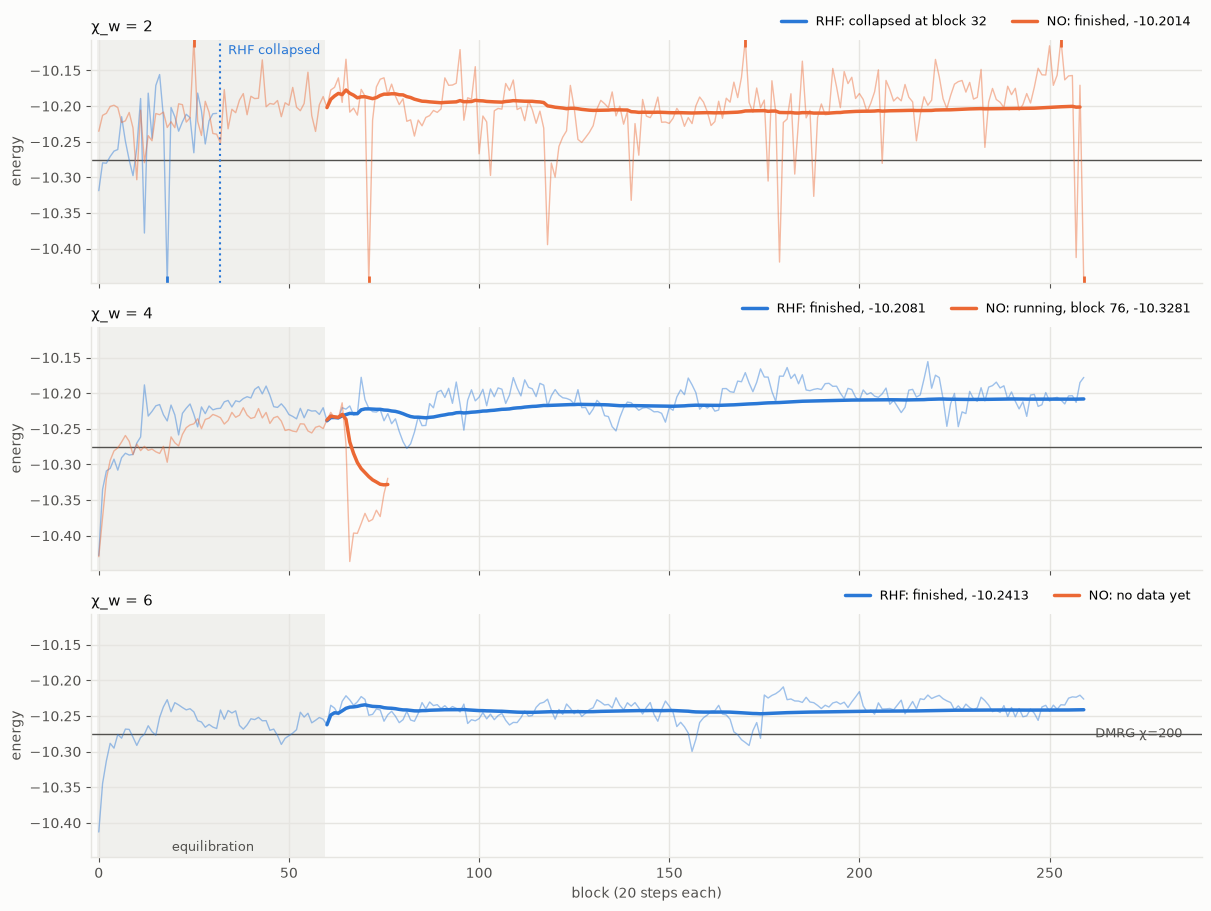

In [7]:
alle = np.concatenate([r["e"] for r in runs8.values() if len(r["e"])])
ylo = min(np.percentile(alle, 0.5), E_ref8) - 0.02
yhi = np.percentile(alle, 99.5) + 0.02
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=True, constrained_layout=True)
for ax, w in zip(axes, CHI_W8):
    ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
    ax.axhline(E_ref8, color=INK2, lw=1)
    for ref, c in REF_COLOR.items():
        r = runs8[(ref, w)]
        label = f"{ref}: {r['status']}" + (f", {r['running'][-1]:.4f}" if "running" in r else "")
        if len(r["b"]):
            ax.plot(r["b"], np.clip(r["e"], ylo, yhi), color=c, lw=1, alpha=0.45)
            out = (r["e"] < ylo) | (r["e"] > yhi)
            ax.plot(r["b"][out], np.clip(r["e"][out], ylo, yhi), "|", ms=10, mew=2, color=c)
        if "running" in r:
            ax.plot(r["kept_b"], r["running"], color=c, lw=2.5, label=label)
        else:
            ax.plot([], [], color=c, lw=2.5, label=label)
        if r["collapsed"] is not None:
            ax.axvline(r["collapsed"], color=c, lw=1.5, ls=":")
            ax.text(r["collapsed"] + 2, yhi - 0.005, f"{ref} collapsed", color=c, va="top", fontsize=9)
    ax.set_ylabel("energy")
    ax.set_title(f"χ_w = {w}", loc="left")
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2, fontsize=9)
axes[-1].text(n_eql / 2, ylo + 0.005, "equilibration", color=INK2, ha="center", va="bottom", fontsize=9)
axes[-1].text(262, E_ref8, "DMRG χ=200", color=INK2, va="center", fontsize=9)
axes[-1].set_xlabel("block (20 steps each)")
axes[0].set_ylim(ylo, yhi)
axes[0].set_xlim(-2, 290)
plt.show()

## U = 8: population health

Top: total walker weight per block. Bottom: cumulative node encounters (log scale). Lines stop at a collapse (dotted).

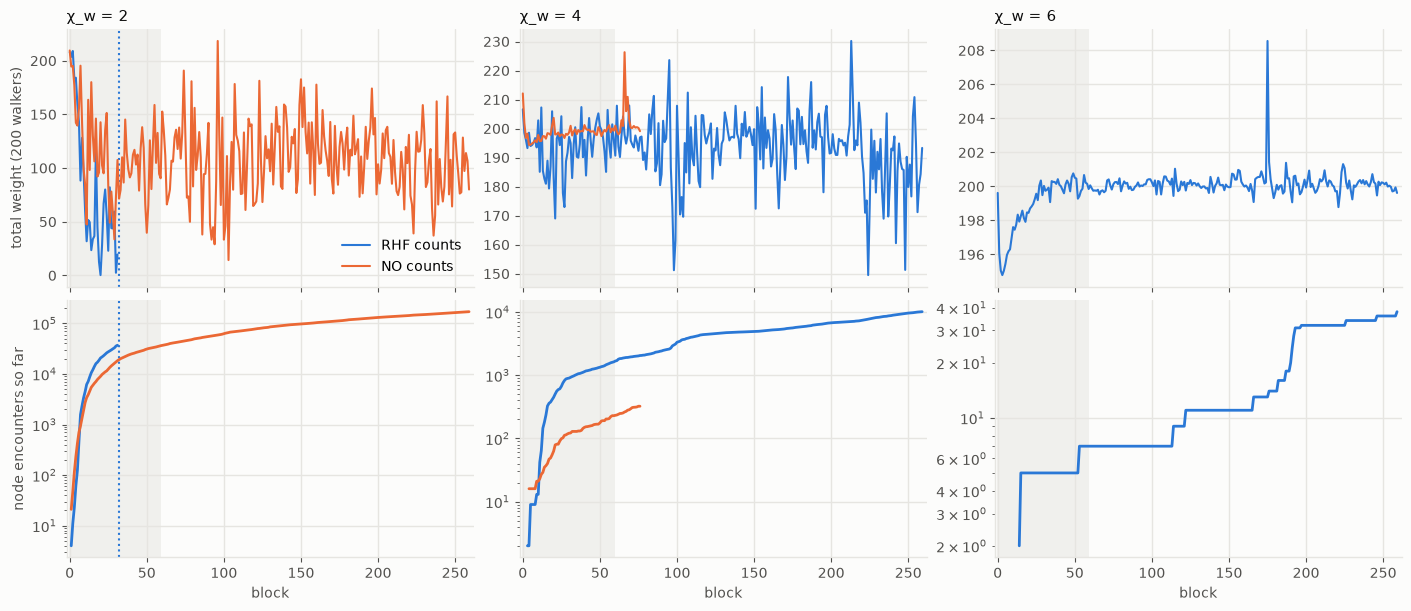

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True, constrained_layout=True)
for j, w in enumerate(CHI_W8):
    for ref, c in REF_COLOR.items():
        r = runs8[(ref, w)]
        axes[0, j].plot(r["b"], r["wt"], color=c, lw=1.5, label=f"{ref} counts")
        n = r["nodes"].astype(float)
        if (n > 0).any():
            axes[1, j].plot(r["b"], np.where(n > 0, n, np.nan), color=c, lw=2)
        if r["collapsed"] is not None:
            for ax in axes[:, j]:
                ax.axvline(r["collapsed"], color=c, lw=1.5, ls=":")
    axes[0, j].set_title(f"χ_w = {w}", loc="left")
    axes[1, j].set_yscale("log")
    axes[1, j].set_xlabel("block")
    for ax in axes[:, j]:
        ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
axes[0, 0].set_ylabel("total weight (200 walkers)")
axes[1, 0].set_ylabel("node encounters so far")
axes[0, 0].legend(loc="lower right")
axes[0, 0].set_xlim(-2, 262)
plt.show()